In [1]:
import pandas as pd

ab_data = pd.read_csv("ab_test_large.csv")
print(ab_data.head())

     group  converted   device  session_duration
0  control          0   tablet             53.40
1  control          1   tablet             53.47
2  control          0   tablet             50.58
3  control          0  desktop             51.33
4  control          0   tablet             69.22


In [2]:
import scipy.stats as stat

In [3]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import scipy.stats as stats

In [4]:
# conversions
conv_old = ab_data[ab_data['group']=='control']['converted'].sum()
conv_new = ab_data[ab_data['group']=='treatment']['converted'].sum()

# total users
n_old = ab_data[ab_data['group']=='control'].shape[0]
n_new = ab_data[ab_data['group']=='treatment'].shape[0]

# Z-test
z_score, p_value = proportions_ztest(
    [conv_new, conv_old],
    [n_new, n_old],
    alternative='larger'
)

print("Z-score:", z_score)
print("p-value:", p_value)

Z-score: 2.574973338759486
p-value: 0.005012390683972185


In [5]:
ci_old = proportion_confint(conv_old, n_old, alpha=0.05)
ci_new = proportion_confint(conv_new, n_new, alpha=0.05)

print("Control CI:", ci_old)
print("Treatment CI:", ci_new)


Control CI: (0.06846363933342858, 0.08313636066657143)
Treatment CI: (0.08206759207535506, 0.09793240792464493)


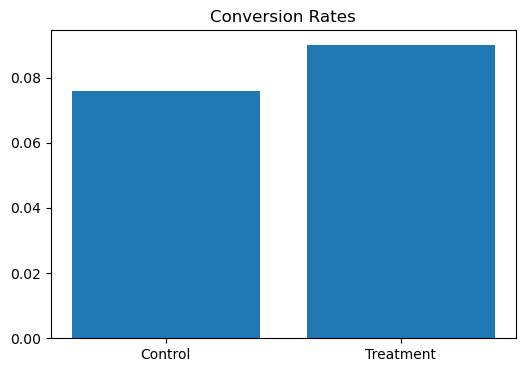

In [6]:
import matplotlib.pyplot as plt

rates = [conv_old/n_old, conv_new/n_new]

plt.figure(figsize=(6,4))
plt.bar(['Control','Treatment'], rates)
plt.title("Conversion Rates")
plt.show()

In [7]:
contingency = pd.crosstab(ab_data['device'], ab_data['converted'])

chi2, p, dof, expected = stats.chi2_contingency(contingency)

print("Chi-square p-value:", p)

Chi-square p-value: 0.1714481181509181


In [8]:
control = ab_data[ab_data['group']=='control']['session_duration']
treatment = ab_data[ab_data['group']=='treatment']['session_duration']

t_stat, p_val = stats.ttest_ind(treatment, control)

print("T-test p-value:", p_val)

T-test p-value: 8.173749025524965e-23
